# Word2Vec + HMM NER Pipeline

This notebook trains Skip-Gram with Negative Sampling embeddings on CoNLL-2003 text, explores the learned vector space, and evaluates a simple HMM-based NER model.

## 1. Imports And Setup


In [18]:
from collections import Counter

from data.conll2003_loader import load_conll2003, load_conll2003_splits
from utils.vocabulary import build_vocab, tokenize
from models.skipgram_model import SkipGramNS
from training.skipgram_trainer import train_skipgram
from utils.embeddings_utils import word_analogy, save_embeddings, most_similar
from data.skipgram_data import create_skipgram_pairs, combine_split_sentences
from models.hmm_ner import HMM_NER
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)

print("Environment ready.")


Environment ready.


## 2. Load And Inspect The Dataset


Loading CoNLL2003 dataset...
Dataset loaded successfully.

Split sizes:
- Train: 14041
- Validation: 3250
- Test: 3453

Total sentences used for skip-gram: 20744
Average sentence length: 14.53 tokens
Median sentence length: 10 tokens

Example sentence:
['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']


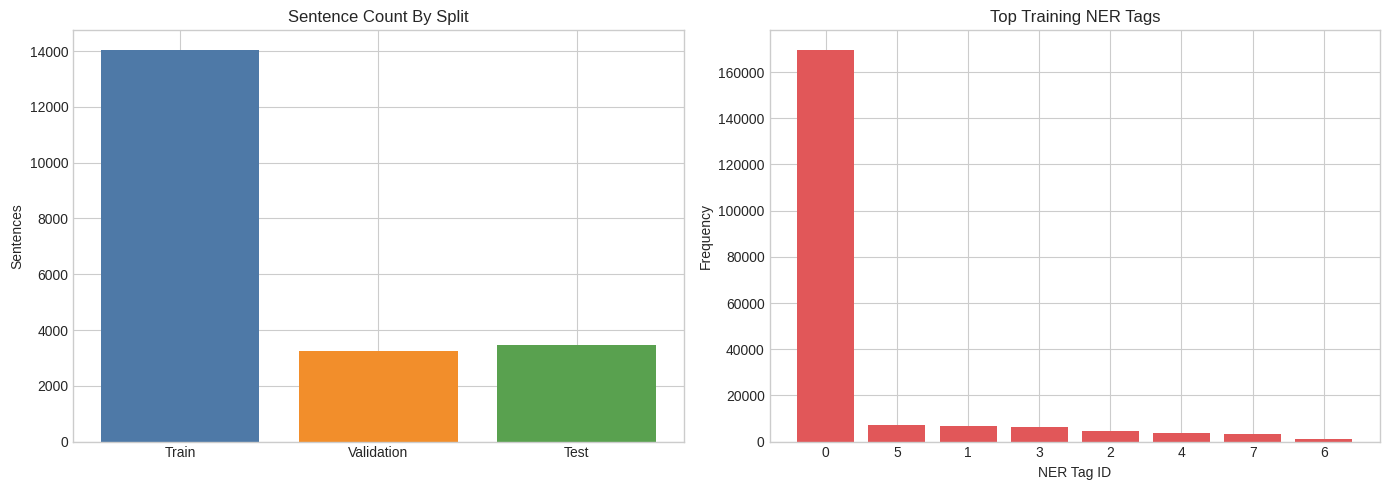

In [19]:
print("Loading CoNLL2003 dataset...")

splits, label_names, id2label, label2id = load_conll2003_splits()

(
    all_tokens,
    train_sentences,
    train_tags,
    validation_sentences,
    validation_tags,
    test_sentences,
    test_true_tags,
    _,
    _,
    _,
) = load_conll2003()


# Use all splits for skip-gram training.
sentences = combine_split_sentences(
    train_sentences, validation_sentences, test_sentences
)

split_sizes = {
    "Train": len(train_sentences),
    "Validation": len(validation_sentences),
    "Test": len(test_sentences),
}

token_lengths = [len(sentence) for sentence in sentences]
tag_counts = Counter(tag for seq in train_tags for tag in seq)
top_tags = tag_counts.most_common(8)

print("Dataset loaded successfully.\n")
print("Split sizes:")
for split_name, split_size in split_sizes.items():
    print(f"- {split_name}: {split_size}")

print(f"\nTotal sentences used for skip-gram: {len(sentences)}")
print(f"Average sentence length: {np.mean(token_lengths):.2f} tokens")
print(f"Median sentence length: {np.median(token_lengths):.0f} tokens")

print("\nExample sentence:")
print(sentences[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    split_sizes.keys(), split_sizes.values(), color=["#4e79a7", "#f28e2b", "#59a14f"]
)
axes[0].set_title("Sentence Count By Split")
axes[0].set_ylabel("Sentences")

axes[1].bar(
    [str(tag) for tag, _ in top_tags], [count for _, count in top_tags], color="#e15759"
)
axes[1].set_title("Top Training NER Tags")
axes[1].set_xlabel("NER Tag ID")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 3. Build The Vocabulary


In [20]:
print("Building vocabulary...")

tokenized = tokenize(sentences)
vocab, idx_to_word = build_vocab(tokenized)
V = len(vocab)

sentence_token_total = sum(len(sentence) for sentence in tokenized)
covered_token_total = sum(sum(1 for word in sentence if word in vocab) for sentence in tokenized)
coverage = covered_token_total / sentence_token_total if sentence_token_total else 0.0

print(f"Vocabulary size: {V}")
print(f"Vocabulary coverage after min_count filtering: {coverage:.2%}")

print("\nSample vocabulary items:")
for word in list(vocab.keys())[:10]:
    print(f"- {word}: {vocab[word]}")


Building vocabulary...
Vocabulary size: 15488
Vocabulary coverage after min_count filtering: 95.09%

Sample vocabulary items:
- EU: 0
- rejects: 1
- German: 2
- call: 3
- to: 4
- boycott: 5
- British: 6
- lamb: 7
- .: 8
- Peter: 9


## 4. Create Skip-Gram Training Pairs


In [21]:
print("Creating Skip-Gram dataset...")

window_size = 2
pairs = create_skipgram_pairs(tokenized, vocab, window_size)

print(f"Window size: {window_size}")
print(f"Number of training pairs: {len(pairs)}")

print("\nSample pairs:")
for target, context in pairs[:10]:
    print(f"- {idx_to_word[target]} -> {idx_to_word[context]}")


Creating Skip-Gram dataset...
Window size: 2
Number of training pairs: 1023428

Sample pairs:
- EU -> rejects
- EU -> German
- rejects -> EU
- rejects -> German
- rejects -> call
- German -> EU
- German -> rejects
- German -> call
- German -> to
- call -> rejects


## 5. Initialize The Skip-Gram Model


In [22]:
embedding_dim = 100

print("Initializing Word2Vec SGNS model...")
model = SkipGramNS(vocab_size=V, embedding_dim=embedding_dim)

print("Model initialized successfully.")
print(f"Embedding dimension: {embedding_dim}")
print(f"Input embedding matrix shape: {model.W_in.shape}")
print(f"Output embedding matrix shape: {model.W_out.shape}")


Initializing Word2Vec SGNS model...
Model initialized successfully.
Embedding dimension: 100
Input embedding matrix shape: (15488, 100)
Output embedding matrix shape: (15488, 100)


## 6. Train The Embedding Model


In [ ]:
epochs = 30

# loss_history = train_skipgram(
#     pairs=pairs,
#     vocab=vocab,
#     model=model,
#     neg_samples=5,
#     lr=0.05,
#     epochs=epochs,
# )

loss_history = train_skipgram(
    pairs=pairs,
    vocab=vocab,
    model=model,
    neg_samples=5,
    lr=0.05,
    epochs=epochs,
    training_mode="mini_batch",
    batch_size=16,
    scale_mini_batch_lr=True,
)

print("Training finished.")
print(f"Initial loss: {loss_history[0]:.4f}")
print(f"Final loss: {loss_history[-1]:.4f}")
print(f"Loss improvement: {loss_history[0] - loss_history[-1]:.4f}")


KeyboardInterrupt: 

## 6.1 Training Visualization


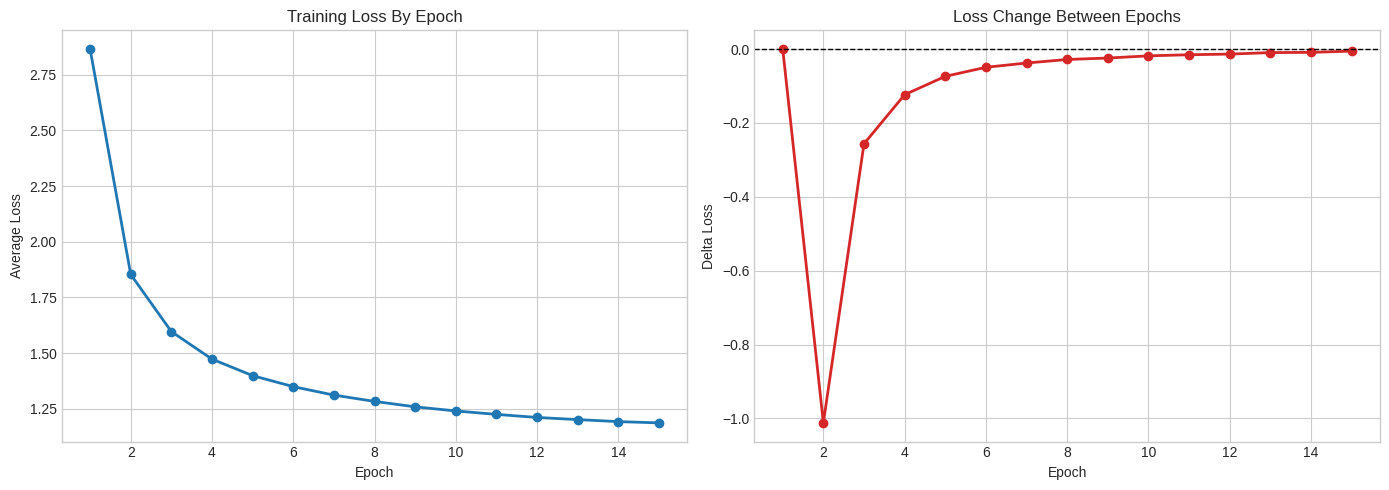

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_axis = np.arange(1, epochs + 1)
axes[0].plot(epochs_axis, loss_history, marker="o", linewidth=2, color="#1f77b4")
axes[0].set_title("Training Loss By Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Average Loss")

axes[1].plot(epochs_axis, np.diff([loss_history[0], *loss_history]), marker="o", linewidth=2, color="#d62728")
axes[1].set_title("Loss Change Between Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Delta Loss")
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")

plt.tight_layout()
plt.show()


## 7. Explore Learned Embeddings


In [ ]:
W_in_norm = model.W_in / (np.linalg.norm(model.W_in, axis=1, keepdims=True) + 1e-9)

test_words = [
    "year", "tournament", "match", "player",
    "team", "percent",
    "Germany", "German", "France", "French",
    "EU", "British",
]

similarity_summary = {}

for word in test_words:
    if word not in vocab:
        similarity_summary[word] = []
        continue
    similarity_summary[word] = most_similar(word, vocab, idx_to_word, W_in_norm, topk=5)

for word, results in similarity_summary.items():
    print(f"\nMost similar words to {word!r}:")
    if not results:
        print("- Word not in vocabulary")
        continue
    for rank, (neighbor, score) in enumerate(results, 1):
        print(f"{rank}. {neighbor:<15} score= {score:.4f}")



Most similar words to 'year':
1. week            score= 0.9117
2. half            score= 0.8950
3. month           score= 0.8898
4. around          score= 0.8800
5. recent          score= 0.8738

Most similar words to 'tournament':
1. race            score= 0.9466
2. Sunday          score= 0.9461
3. Prix            score= 0.9431
4. tennis          score= 0.9428
5. matches         score= 0.9399

Most similar words to 'match':
1. soccer          score= 0.9486
2. championship    score= 0.9399
3. matches         score= 0.9373
4. Series          score= 0.9197
5. tournament      score= 0.9183

Most similar words to 'player':
1. recorded        score= 0.9895
2. present         score= 0.9894
3. broke           score= 0.9890
4. plays           score= 0.9885
5. film            score= 0.9884

Most similar words to 'team':
1. race            score= 0.8879
2. record          score= 0.8862
3. test            score= 0.8858
4. hurdles         score= 0.8738
5. series          score= 0.8708

Most simil

## 8. Save Embeddings


In [ ]:
embeddings_file = "embeddings.txt"
save_embeddings(model.W_in, idx_to_word, embeddings_file)
print(f"Embeddings saved to {embeddings_file}")


Embeddings saved to embeddings.txt


## 9. Word Analogy Checks


In [ ]:
analogy_tests = [
    ("Germany", "German", "France"),
    ("France", "French", "Germany"),
    ("Kohl", "Germany", "Chirac"),
    ("Clinton", "America", "Kohl"),
    ("EU", "Europe", "UN"),
    ("Paris", "France", "Rome"),
    ("president", "government", "minister"),
    ("year", "years", "month"),
    ("match", "team", "tournament"),
]

for a, b, c in analogy_tests:
    print(f"\n{a} : {b} :: {c} : ?")
    if a not in vocab or b not in vocab or c not in vocab:
        print("- Skipped because one or more words are missing from the vocabulary")
        continue
    results = word_analogy(a, b, c, W_in_norm, vocab, idx_to_word, topk=5)
    for rank, (word, score) in enumerate(results, 1):
        print(f"{rank}. {word:<15} score={score:.4f}")



Germany : German :: France : ?
1. French          score=0.9482
2. Dutch           score=0.9365
3. leaders         score=0.9204
4. Italian         score=0.9162
5. Russian         score=0.9146

France : French :: Germany : ?
1. leaders         score=0.9377
2. Italian         score=0.9347
3. Belgian         score=0.9346
4. German          score=0.9317
5. Dutch           score=0.9289

Kohl : Germany :: Chirac : ?
1. Sweden          score=0.9529
2. Italy           score=0.9497
3. 8.              score=0.9493
4. 5.              score=0.9481
5. Russia          score=0.9468

Clinton : America :: Kohl : ?
1. 299             score=0.9570
2. 1/3             score=0.9542
3. 406             score=0.9538
4. Bromwich        score=0.9538
5. Nantes          score=0.9537

EU : Europe :: UN : ?
1. inning          score=0.9704
2. crash           score=0.9656
3. seventh         score=0.9648
4. conflict        score=0.9628
5. ninth           score=0.9625

Paris : France :: Rome : ?
1. Britain         score

## 10. Train And Evaluate The HMM NER Model


In [ ]:
hmm = HMM_NER(unk_threshold=1, k_trans=0.5, k_emit=0.1, use_bio_constraints=True)
hmm.train(train_sentences, train_tags)

predicted_tags = [hmm.viterbi(sentence) for sentence in test_sentences]

flat_true = [tag for seq in test_true_tags for tag in seq]
flat_pred = [tag for seq in predicted_tags for tag in seq]


accuracy = accuracy_score(flat_true, flat_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print(classification_report(flat_true, flat_pred, zero_division=0))

example_idx = 14
print("Tokens:      ", test_sentences[example_idx])
print("True tags:   ", [id2label.get(t, str(t)) for t in test_true_tags[example_idx]])
print("Predicted:   ", [id2label.get(t, str(t)) for t in predicted_tags[example_idx]])

Accuracy: 0.9423

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     38323
           1       0.84      0.72      0.78      1617
           2       0.82      0.97      0.89      1156
           3       0.67      0.69      0.68      1661
           4       0.69      0.73      0.71       835
           5       0.89      0.77      0.83      1668
           6       0.72      0.61      0.66       257
           7       0.80      0.69      0.74       702
           8       0.58      0.69      0.63       216

    accuracy                           0.94     46435
   macro avg       0.78      0.76      0.77     46435
weighted avg       0.94      0.94      0.94     46435

Tokens:       ['Japan', 'then', 'laid', 'siege', 'to', 'the', 'Syrian', 'penalty', 'area', 'for', 'most', 'of', 'the', 'game', 'but', 'rarely', 'breached', 'the', 'Syrian', 'defence', '.']
True tags:    ['B-LOC', 'O', 'O', 'O', 'O', 'O', 'B-MISC', 'O', 'O', 'O', 'O', 'O', 'O',